<a href="https://colab.research.google.com/github/M7office/visualization/blob/assignment-3/Viz%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

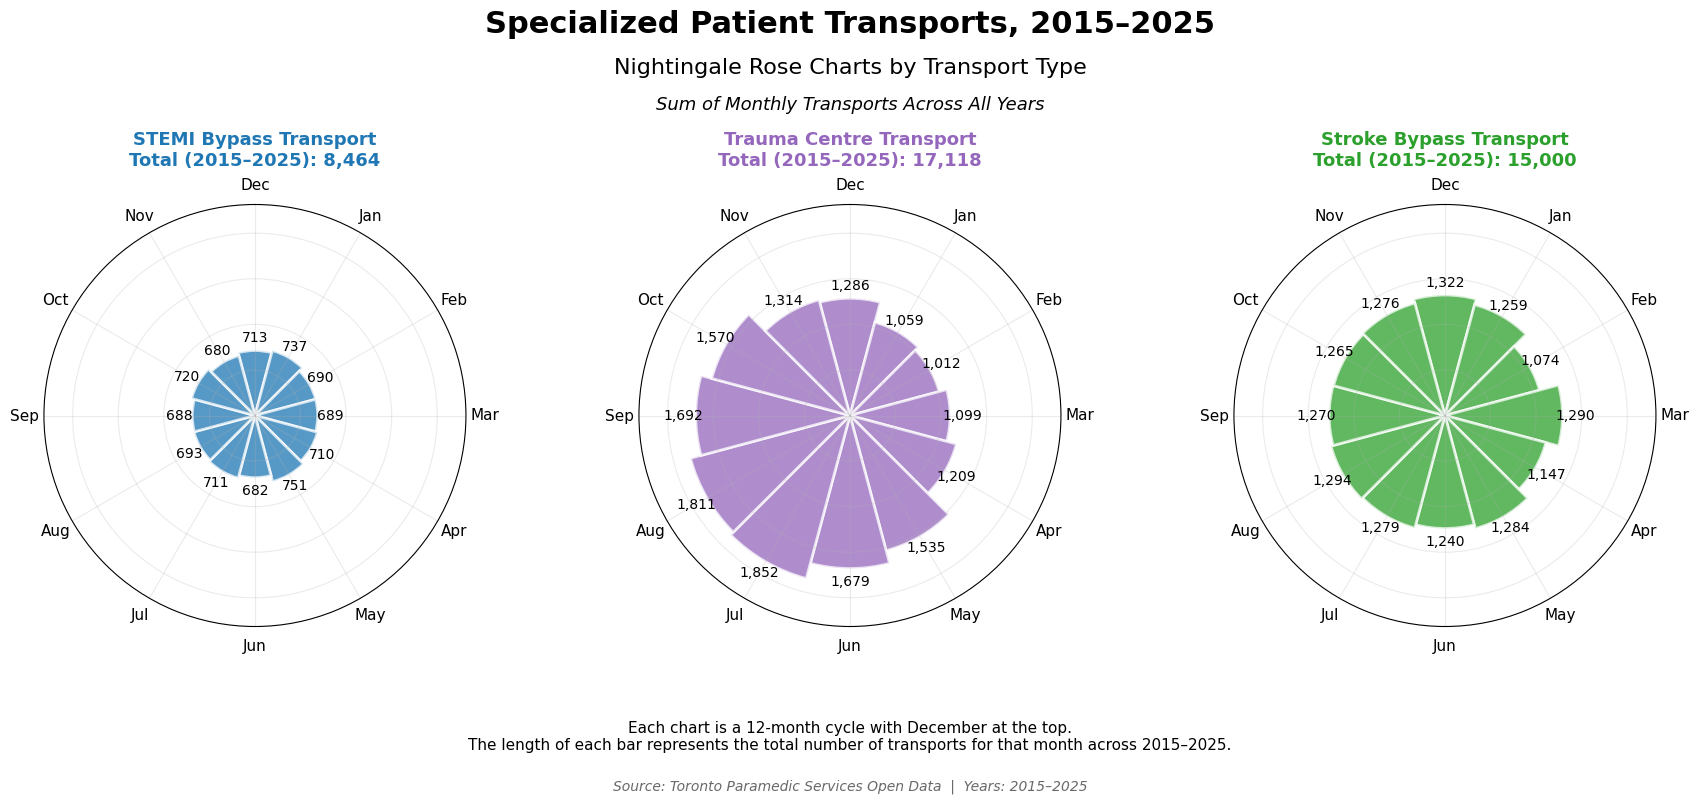

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "specialized-patient-transports-data-2015-2025.xlsx"

sheets = [
    "STEMI Bypass Transports",
    "Stroke Bypass Transports",
    "Trauma Centre Transports"
]

df = pd.concat(
    [pd.read_excel(file_path, sheet_name=s) for s in sheets],
    ignore_index=True
)

month_order = [
    "December", "January", "February", "March", "April", "May",
    "June", "July", "August", "September", "October", "November"
]

month_labels = [
    "Dec", "Jan", "Feb", "Mar", "Apr", "May",
    "Jun", "Jul", "Aug", "Sep", "Oct", "Nov"
]

summary = (
    df.groupby(["Specialized Transport Type", "Month"])["Count"]
    .sum()
    .reset_index()
)

summary["Month"] = pd.Categorical(
    summary["Month"],
    categories=month_order,
    ordered=True
)

summary = summary.sort_values("Month")

transport_types = summary["Specialized Transport Type"].unique()
colors = ["#1f77b4", "#9467bd", "#2ca02c"]

global_max = summary["Count"].max()

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    subplot_kw={"projection": "polar"}
)

for ax, transport_type, color in zip(axes, transport_types, colors):
    data = summary[summary["Specialized Transport Type"] == transport_type]
    counts = data["Count"].values
    total_count = counts.sum()

    angles = np.linspace(0, 2 * np.pi, len(month_order), endpoint=False)
    width = 2 * np.pi / len(month_order)

    ax.bar(
        angles,
        counts,
        width=width,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=2
    )

    ax.set_ylim(0, global_max * 1.25)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_xticks(angles)
    ax.set_xticklabels(month_labels, fontsize=11)

    ax.set_yticklabels([])
    ax.grid(alpha=0.25)

    ax.set_title(
        f"{transport_type}\nTotal (2015–2025): {total_count:,}",
        fontsize=13,
        fontweight="bold",
        color=color,
        pad=28
    )

    # count numbers outside bars
    for angle, count in zip(angles, counts):
        ax.text(
            angle,
            count + global_max * 0.075,
            f"{count:,}",
            ha="center",
            va="center",
            fontsize=10,
            color="black"
        )

fig.suptitle(
    "Specialized Patient Transports, 2015–2025",
    fontsize=22,
    fontweight="bold",
    y=0.99
)

# more space between title and subtitle
fig.text(
    0.5,
    0.91,
    "Nightingale Rose Charts by Transport Type",
    ha="center",
    fontsize=16
)

fig.text(
    0.5,
    0.865,
    "Sum of Monthly Transports Across All Years",
    ha="center",
    fontsize=13,
    style="italic"
)


fig.text(
    0.5,
    0.065,
    "Each chart is a 12-month cycle with December at the top.\n"
    "The length of each bar represents the total number of transports for that month across 2015–2025.",
    ha="center",
    fontsize=11,


)

fig.text(
    0.5,
    0.015,
    "Source: Toronto Paramedic Services Open Data  |  Years: 2015–2025",
    ha="center",
    fontsize=10,
    style="italic",
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.20, 1, 0.82])

plt.savefig(
    "nightingale_rose_patient_transports_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**What software did you use to create your data visualization?**

Python

**Who is your intended audience?**

My intended audience is emergency medical service planners, and Toronto health system decision-makers.

**What information or message are you trying to convey with your visualization?**

The visualization shows how specialized patient transports are distributed across months from 2015–2025. It highlights possible seasonal patterns which suggests optimizing allocation of emergency resources/supplies across month and transport types.

**What aspects of design did you consider when making your visualization?**

- I used a circular layout with December placed at the top, like a clock, and the months move clockwise.
- I used three separate charts so each transport type can be viewed clearly.
- I also used the same radial scale across charts so the three transport types can be compared fairly.

**How did you ensure that your data visualizations are reproducible?**

The chart was created using Python code.

**How did you ensure that your data visualization is accessible?**

I used three colors to seperate the three transport types in charts. But the count labels are placed in black color so they are easier to read.

**Who are the individuals and communities who might be impacted by your visualization?**

Patients, paramedics, hospitals, emergency departments, and Toronto communities may be impacted. The chart could support planning for emergency transport demand.

**How did you choose which features of your chosen dataset to include or exclude?**

- I included transport type, month, and count because they directly support the goal of showing monthly transport patterns from 2015–2025.
- I excluded evolution pattern over years that were not needed for seasonal comparison.

**What ‘underwater labour’ contributed to your final data visualization product?**

- People who collected data and offered TI support for making it open online
- The hidden viz work included improving readability.